In [1]:
import torch
import torchvision
from model import VAE
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F
import numpy as np
from torchvision.utils import make_grid
from torchvision.transforms import v2
from torch.utils.data import DataLoader
from tqdm import tqdm, trange
from torch.nn.functional import l1_loss

In [2]:
transform = v2.Compose([
    v2.Resize((128, 128), interpolation=v2.InterpolationMode.BICUBIC),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])
celeba = torchvision.datasets.CelebA(root='../datasets', split='all', transform=transform, download=False)
celeba_loader = DataLoader(celeba, batch_size=16, shuffle=False, num_workers=4)

In [3]:
def show_img(img, figsize=None, ax=None):
    if not ax:
        fig = plt.figure(figsize=figsize)
        ax = fig.add_subplot()
    img = img.detach()
    img = F.to_pil_image(img)
    ax.imshow(np.asarray(img), cmap='gray')
    ax.set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

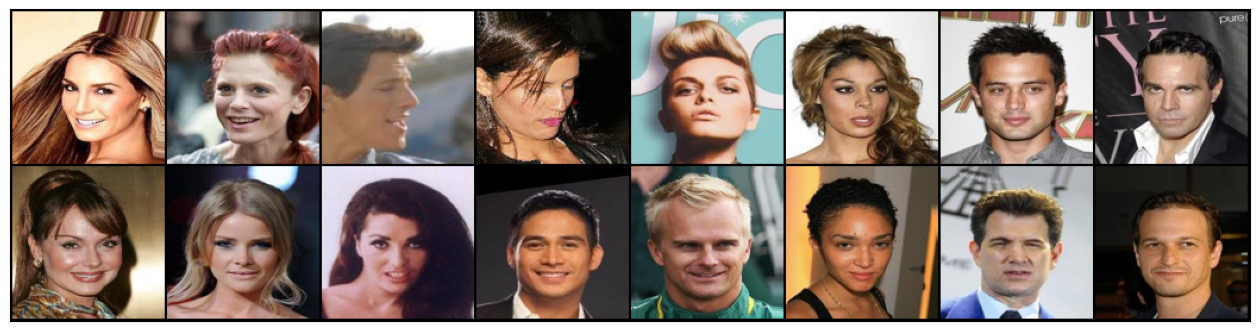

In [4]:
imgs_raw, labels = next(celeba_loader.__iter__())
show_img(make_grid(imgs_raw), figsize=(16, 8))

In [5]:
X, mean, std = torch.load('../datasets/celeba_embeddings_normalized.pt').values()

/tmp/user/5678/ipykernel_3162941/2916273196.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  X, mean, std = torch.load('../datasets/celeba_embeddings_normalized.pt').valu

In [7]:
std

tensor([3.9288, 4.4087, 3.7422, 2.9430])

In [4]:
torch.load('checkpoints/latent_vae_epoch_106.pt')['total_loss']

/tmp/user/5678/ipykernel_3100154/3917437836.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load('checkpoints/latent_vae_epoch_106.pt')['total_loss']


0.07753034743302328

In [23]:
from model import VAE as ModernVAE
class ModernLatentVAE():
    def __init__(self, epoch: int, device='cuda'):
        self.device = device
        self.model = ModernVAE(latent_features=64, img_channels=4)
        # self.model.load_state_dict(torch.load('checkpoints/latent_vae_epoch_106.pt')['state_dict'])
        self.model.load_state_dict(torch.load(f'checkpoints/continued/latent_vae_epoch_{epoch}.pt')['state_dict'])
        self.model.to(self.device)
        self.model.eval()

    def encode(self, data: torch.Tensor) -> torch.Tensor:
        og_device = data.device
        data = data.to(self.device)
        is_single_image = data.ndim == 3
        if is_single_image:
            data = data.unsqueeze(0)
        latent = self.model.encode(data)
        if is_single_image:
            latent = latent[0]
        return latent.to(og_device)
    
    def decode(self, latent: torch.Tensor) -> torch.Tensor:
        og_device = latent.device
        latent = latent.to(self.device)
        is_single_image = latent.ndim == 1
        if is_single_image:
            latent = latent.unsqueeze(0)
        data = self.model.decode(latent)
        if is_single_image:
            data = data[0]
        return data.to(og_device)
    
    def reconstruct(self, data: torch.Tensor) -> torch.Tensor:
        og_device = data.device
        data = data.to(self.device)
        reconstructed = self.decode(self.encode(data))
        return reconstructed.to(og_device)
    


In [9]:
latent_vae = ModernLatentVAE()

/tmp/user/5678/ipykernel_3162941/2334398245.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load('checkpoints/continued/latent_vae_epoch

In [10]:
from diffusers.models.autoencoders.autoencoder_kl import AutoencoderKL
class StableDiffusionVAE:
    def __init__(self, device='cuda'):
        self.device = device
        self.model = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse").to(device) #type:ignore
        self.model.eval()
    
    def encode(self, data: torch.Tensor) -> torch.Tensor:
        og_device = data.device
        data = data.to(self.device)
        is_single_image = data.ndim == 3
        if is_single_image:
            data = data.unsqueeze(0)
        latent = self.model.encode(data)[0].mode()
        if is_single_image:
            latent = latent[0]
        # return latent.flatten(start_dim=-3).to(og_device)
        return latent.to(og_device)
    
    def decode(self, latent: torch.Tensor) -> torch.Tensor:
        og_device = latent.device
        # width = int(np.sqrt(latent.shape[-1] // 4))
        is_single_image = latent.ndim == 3
        # latent = latent.reshape(-1, 4, width, width).to(self.device)
        if is_single_image:
            latent = latent.unsqueeze(0)
        latent = latent.to(self.device)
        data = self.model.decode(latent)[0] #type:ignore
        if is_single_image:
            data = data[0]
        return data.to(og_device)
    
    def reconstruct(self, data: torch.Tensor) -> torch.Tensor:
        og_device = data.device
        data = data.to(self.device)
        reconstructed = self.decode(self.encode(data))
        return reconstructed.to(og_device)   

/net/st1/export/clusterhome/robertwiebe/testvenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
diff_vae = StableDiffusionVAE()

/net/st1/export/clusterhome/robertwiebe/testvenv/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


In [12]:
denorm = lambda x: x * std[..., None, None] + mean[..., None, None]
norm = lambda x: (x - mean[..., None, None]) / std[..., None, None]

In [13]:
imgs = X[:16]

In [15]:
X_no_norm, _ = torch.load('../datasets/celeba_embeddings.pt')
imgs_nonorm = X_no_norm[:16]

/tmp/user/5678/ipykernel_3100154/2084419921.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  X_no_norm, _ = torch.load('../datasets/celeba_embeddings.pt')


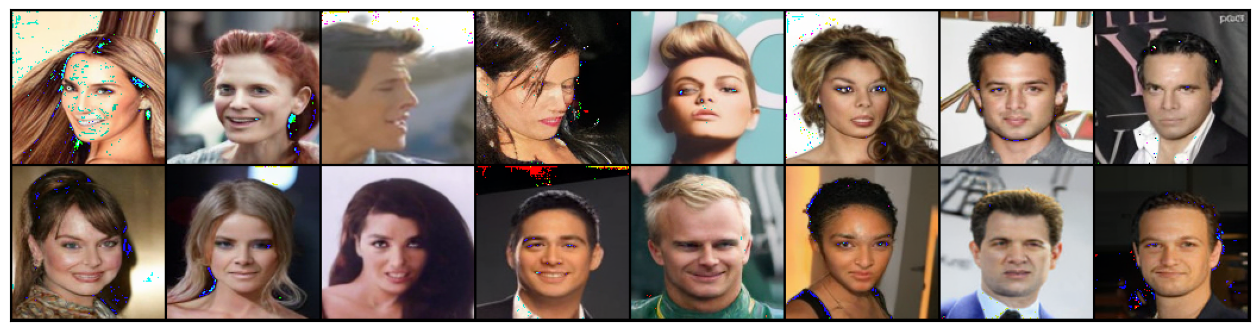

In [14]:
show_img(make_grid(diff_vae.decode(denorm(imgs))), figsize=(16, 8))

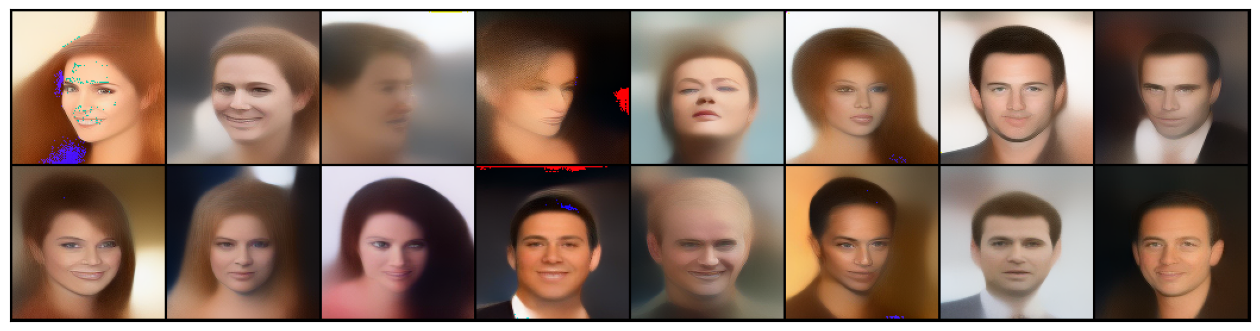

In [59]:
show_img(make_grid(diff_vae.decode(denorm(latent_vae.reconstruct(imgs)))), figsize=(16, 8))

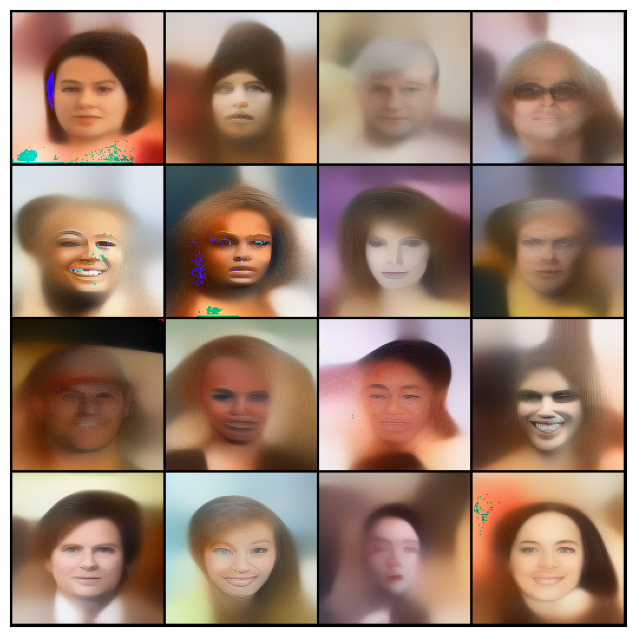

In [81]:
show_img(make_grid(diff_vae.decode(denorm(latent_vae.decode(torch.randn(16, 64)))), nrow=4), figsize=(16, 8))

In [71]:
old_img = diff_vae.decode(denorm(latent_vae.reconstruct(imgs[9])))

In [78]:
latent_vae = ModernLatentVAE(epoch=150)

/tmp/user/5678/ipykernel_3162941/445917032.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(f'checkpoints/continued/latent_vae_epoch

In [28]:
latent_vae.load_state_dict(torch.load('checkpoints/latent_vae_epoch_106.pt')['state_dict'])

/tmp/user/5678/ipykernel_3099788/713782963.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  latent_vae.load_state_dict(torch.load('checkpoints/latent_vae_epoch_106.pt')['

<All keys matched successfully>

## Trying optimization tricks

### Optimizing latent

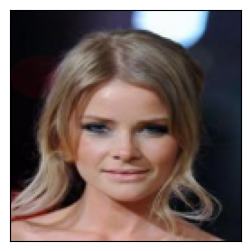

In [13]:
test_img = imgs_raw[9]
show_img(test_img, figsize=(3, 3))

In [14]:
test_med_latent = diff_vae.encode(test_img)

In [58]:
test_med_latent_normed = norm(test_med_latent)

In [34]:
test_small_latent = latent_vae.encode(norm(test_med_latent))

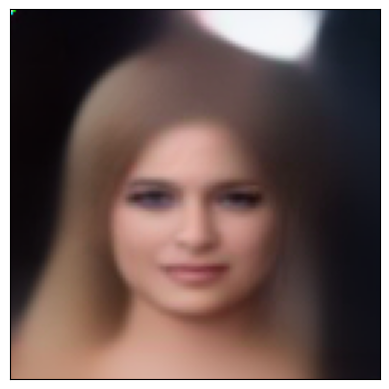

In [35]:
show_img(diff_vae.decode(denorm(latent_vae.decode(test_small_latent))))

In [40]:
optim_latent = test_small_latent.clone().detach().requires_grad_()

In [101]:
optimizer = torch.optim.Adam([optim_latent], lr=1e-4)

In [51]:
N_STEPS = 1000
pbar = trange(N_STEPS, desc='Optimizing latent')
for _ in pbar:
    reconstr = diff_vae.decode(denorm(latent_vae.decode(optim_latent)))
    loss = l1_loss(reconstr, test_img)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    pbar.set_postfix(loss=loss.item())

Optimizing latent: 100%|██████████| 1000/1000 [00:43<00:00, 23.14it/s, loss=0.0594]


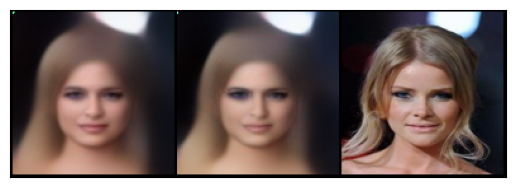

In [52]:
with torch.no_grad():
    show_img(make_grid(torch.stack((
        diff_vae.decode(denorm(latent_vae.decode(test_small_latent))),
        diff_vae.decode(denorm(latent_vae.decode(optim_latent.detach()))),
        test_img
    ))))

### Optimizing latent decoder

In [111]:
tuned_latent_vae = ModernVAE(latent_features=64, img_channels=4).cuda()
tuned_latent_vae.load_state_dict(torch.load('checkpoints/latent_vae_epoch_106.pt')['state_dict'])

/tmp/user/5678/ipykernel_3101402/2178152801.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  tuned_latent_vae.load_state_dict(torch.load('checkpoints/latent_vae_epoch_106

<All keys matched successfully>

### Trying to get it to match medium latent exactly

In [112]:
optimizer = torch.optim.Adam(tuned_latent_vae.decoder.parameters())

In [113]:
small_latent = test_small_latent.detach().cuda()

In [114]:
med_latent = test_med_latent_normed.detach().cuda()

In [117]:
N_STEPS = 20
pbar = trange(N_STEPS, desc='Optimizing latent')
for _ in pbar:
    reconstr = tuned_latent_vae.decode(small_latent.unsqueeze(0))[0]
    loss = l1_loss(reconstr, med_latent)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    pbar.set_postfix(loss=loss.item())

Optimizing latent: 100%|██████████| 20/20 [00:00<00:00, 176.15it/s, loss=0.0439]


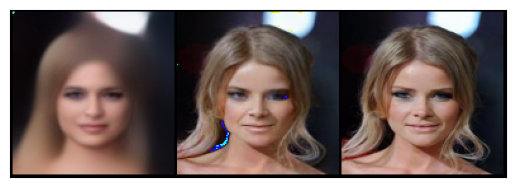

In [118]:
with torch.no_grad():
    show_img(make_grid(torch.stack((
        diff_vae.decode(denorm(latent_vae.decode(test_small_latent))),
        diff_vae.decode(denorm(tuned_latent_vae.decode(small_latent.unsqueeze(0))[0].cpu())),
        test_img
    ))))

In [96]:
std_cuda = std.cuda()
mean_cuda = mean.cuda()
denorm_cuda = lambda x: x * std_cuda[..., None, None] + mean_cuda[..., None, None]

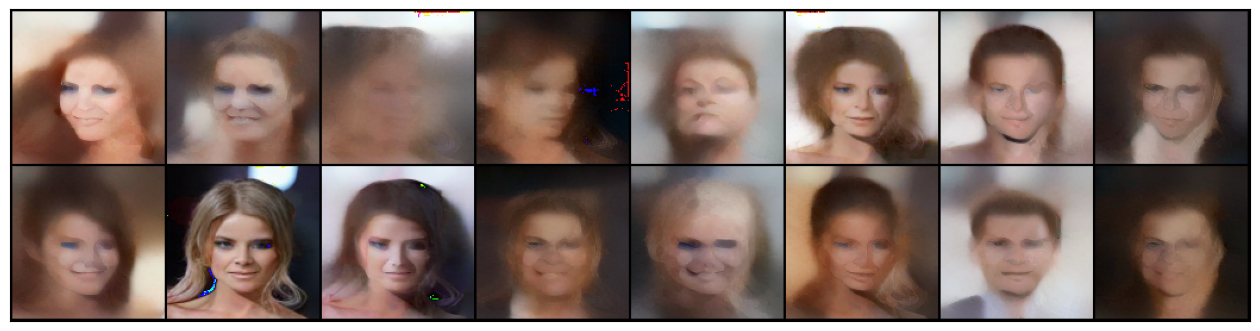

In [121]:
with torch.no_grad():
    show_img(make_grid(diff_vae.decode(denorm_cuda(tuned_latent_vae.reconstruct(imgs.cuda())))), figsize=(16, 8))

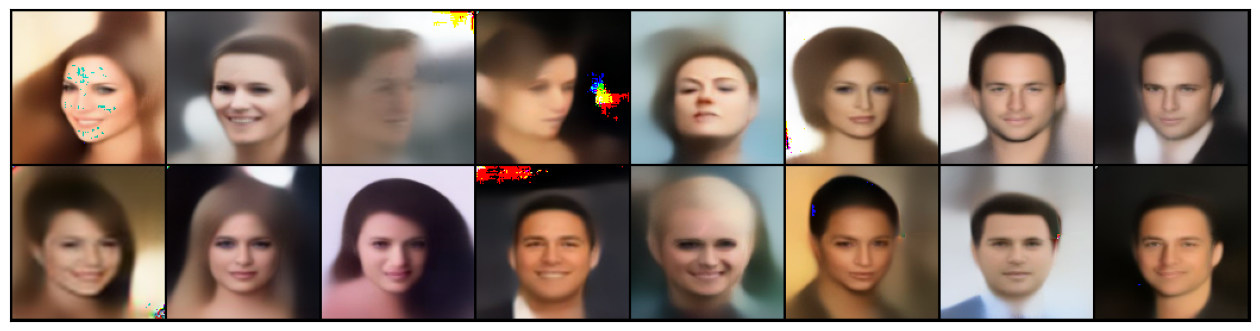

In [122]:
with torch.no_grad():
    show_img(make_grid(diff_vae.decode(denorm(latent_vae.reconstruct(imgs)))), figsize=(16, 8))

### Trying to get it to match image exactly

In [94]:
test_img_cuda = test_img.cuda()

In [109]:
N_STEPS = 100
pbar = trange(N_STEPS, desc='Optimizing latent')
for _ in pbar:
    reconstr = diff_vae.decode(denorm_cuda(tuned_latent_vae.decode(small_latent.unsqueeze(0))[0]))
    loss = l1_loss(reconstr, test_img_cuda)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    pbar.set_postfix(loss=loss.item())

Optimizing latent: 100%|██████████| 100/100 [00:03<00:00, 27.13it/s, loss=0.0179]


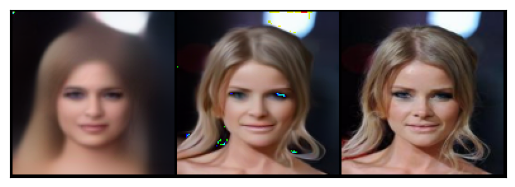

In [110]:
with torch.no_grad():
    show_img(make_grid(torch.stack((
        diff_vae.decode(denorm(latent_vae.decode(test_small_latent))),
        diff_vae.decode(denorm(tuned_latent_vae.decode(small_latent.unsqueeze(0))[0].cpu())),
        test_img
    ))))